<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tamanho treino:", X_train.shape, y_train.shape)
print("Tamanho teste :", X_test.shape, y_test.shape)

Tamanho treino: (120, 4) (120,)
Tamanho teste : (30, 4) (30,)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Acurácia no treino: {acc_train:.4f}")
print(f"Acurácia no teste : {acc_test:.4f}")

Acurácia no treino: 1.0000
Acurácia no teste : 0.9333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

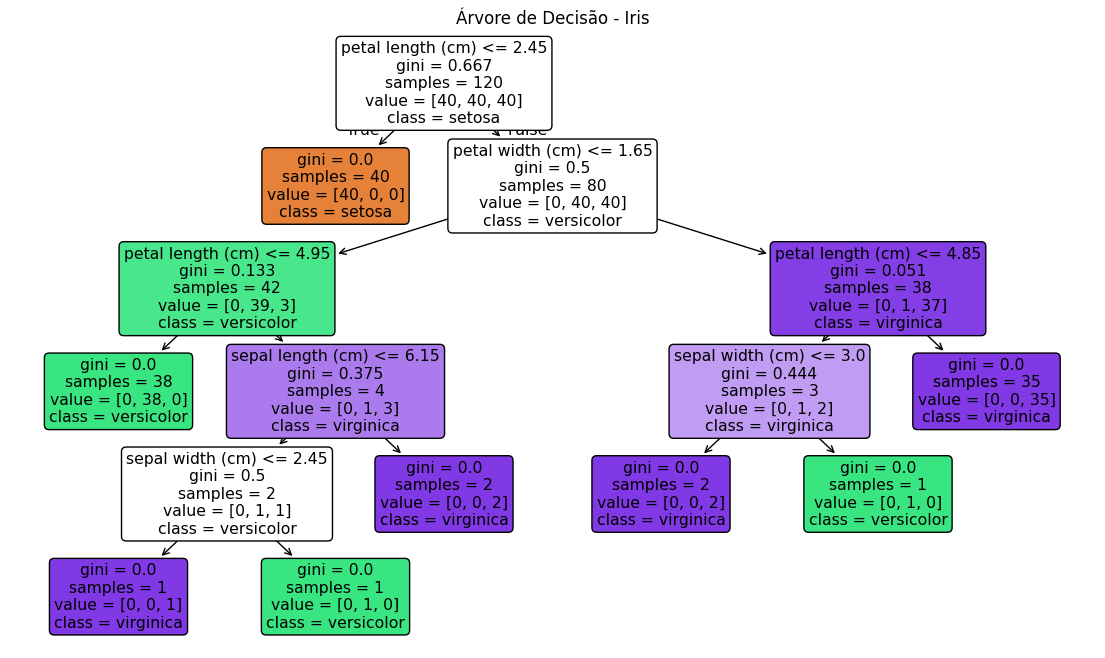

Atributo na raiz: petal length (cm)
Profundidade da árvore: 5


In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Árvore de Decisão - Iris")
plt.show()

root_feature_idx = clf.tree_.feature[0]
root_feature_name = iris.feature_names[root_feature_idx]
depth = clf.get_depth()

print(f"Atributo na raiz: {root_feature_name}")
print(f"Profundidade da árvore: {depth}")

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

max_depth_values = list(range(1, 10)) + [None]
rows = []

for md in max_depth_values:
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    rows.append({
        "max_depth": md,
        "acurácia_treino": accuracy_score(y_train, y_train_pred),
        "acurácia_teste": accuracy_score(y_test, y_test_pred),
        "profundidade_árvore": model.get_depth(),
        "número_folhas": model.get_n_leaves()
    })

resultados_q4 = pd.DataFrame(rows)
resultados_q4["max_depth"] = resultados_q4["max_depth"].astype("object").where(
    resultados_q4["max_depth"].notna(), "None"
)

display(resultados_q4)

,max_depth,acurácia_treino,acurácia_teste,profundidade_árvore,número_folhas
0,1.0,0.666667,0.666667,1,2
1,2.0,0.966667,0.933333,2,3
2,3.0,0.983333,0.966667,3,5
3,4.0,0.991667,0.933333,4,7
4,5.0,1.000000,0.933333,5,8
5,6.0,1.000000,0.933333,5,8
6,7.0,1.000000,0.933333,5,8
7,8.0,1.000000,0.933333,5,8
8,9.0,1.000000,0.933333,5,8
9,None,1.000000,0.933333,5,8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

resultados_q5 = []

for crit in ["gini", "entropy"]:
    model = DecisionTreeClassifier(criterion=crit, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    resultados_q5.append({
        "criterion": crit,
        "profundidade_árvore": model.get_depth(),
        "acurácia_treino": accuracy_score(y_train, y_train_pred),
        "acurácia_teste": accuracy_score(y_test, y_test_pred),
    })

resultados_q5 = pd.DataFrame(resultados_q5)
display(resultados_q5)

,criterion,profundidade_árvore,acurácia_treino,acurácia_teste
0,gini,5,1.0,0.933333
1,entropy,5,1.0,0.933333


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

valores_leaf = [1, 2, 3, 4, 5, 8, 10]
linhas = []

for leaf in valores_leaf:
    model = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    linhas.append({
        "min_samples_leaf": leaf,
        "acurácia_treino": accuracy_score(y_train, y_train_pred),
        "acurácia_teste": accuracy_score(y_test, y_test_pred),
        "profundidade_árvore": model.get_depth(),
        "número_folhas": model.get_n_leaves()
    })

resultados_q6 = pd.DataFrame(linhas).sort_values(
    by=["acurácia_teste", "acurácia_treino"],
    ascending=False
).reset_index(drop=True)

display(resultados_q6)

melhor_leaf = int(resultados_q6.loc[0, "min_samples_leaf"])
melhor_modelo = DecisionTreeClassifier(min_samples_leaf=melhor_leaf, random_state=42)
melhor_modelo.fit(X_train, y_train)

acc_train_best = accuracy_score(y_train, melhor_modelo.predict(X_train))
acc_test_best = accuracy_score(y_test, melhor_modelo.predict(X_test))

print(f"Melhor modelo encontrado: min_samples_leaf={melhor_leaf}")
print(f"Acurácia (treino): {acc_train_best:.4f}")
print(f"Acurácia (teste) : {acc_test_best:.4f}")
print(f"Parâmetros: {melhor_modelo.get_params()}")

,min_samples_leaf,acurácia_treino,acurácia_teste,profundidade_árvore,número_folhas
0,3,0.983333,0.966667,3,5
1,4,0.983333,0.966667,3,5
2,1,1.000000,0.933333,5,8
3,2,0.983333,0.933333,4,6
4,5,0.966667,0.933333,3,5
5,8,0.966667,0.933333,3,5
6,10,0.966667,0.933333,3,5


Melhor modelo encontrado: min_samples_leaf=3
Acurácia (treino): 0.9833
Acurácia (teste) : 0.9667
Parâmetros: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 3, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
